## COMPAS - 2 OBJECTIVES

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectiv    es:** Non-white and White individuals

### Methods

* **ML_MOO**
* **MONISE**
* **Random Weights**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from ml_moo import moo
from ml_moo import get_objectives
from ml_moo import run_ensemble
from ml_moo import MooScalarization
from ml_moo.analysis.metrics import compute_hypervolume_progress
from ml_moo.analysis.visualization import plot_pareto_2d, plot_parallel_coordinates, plot_hypervolume


ModuleNotFoundError: No module named 'moo_analyzer'

### Dataset and Model

In [ ]:
# Setting a seed for reproducibility
seed = 42

In [ ]:
data = pd.read_csv("dataset/compas_onerace.csv")
fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"
data = data.drop("Unnamed: 0", axis=1)

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)


In [ ]:
tol = 10**-3
max_iter = 100
lambd = math.exp(-100)

model = LogisticRegression(solver = 'lbfgs',
                           class_weight = None,
                           penalty = 'l2',
                           max_iter = max_iter,
                           tol = tol, 
                           C = 1/lambd,
                           warm_start = True)

In [ ]:
def train_logreg_fair(model, X, y, fair_feat, fair_att, w):
    """
    Treina o modelo com sample weights balanceadas por grupo de fairness.
    Retorna a loss por grupo.
    """
    # Gera os sample_weights com base nos grupos
    fair_weight = w
    sample_weight = X[fair_feat].replace({
        ff: fw / sum(X[fair_feat] == ff) 
        for ff, fw in zip(fair_att, fair_weight)
    }) + 1e-20

    # Treina o modelo
    model.fit(X, y, sample_weight=sample_weight.to_numpy())

    # Avaliação: log_loss por grupo
    y_pred = model.predict_proba(X)
    objs = []
    for i, feat in enumerate(fair_att):
        group_weight = X[fair_feat].replace({
            ff: 1 if ff == feat else 0 for ff in fair_att
        })
        objs.append(log_loss(y, y_pred, sample_weight=group_weight.to_numpy()))
    return np.array(objs)

In [ ]:
fair_feat = fair_feature
fair_att = sorted(X[fair_feat].unique())

# Train function to be passed in scalarization
def train_fn_logreg(model, w):
    return train_logreg_fair(model, X, y, fair_feat, fair_att, w)

## Multi Objective Optimization Process

In [ ]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}

In [ ]:
num_objs = 2
w_scalar = MooScalarization(model, train_fn_logreg, num_objs)

In [ ]:
# Logistic Regression with equal weight to use as baseline
equal = MooScalarization(model, train_fn_logreg, 2)
equal.optimize(np.array([0.5, 0.5]))

In [ ]:
methods = [
    'mola', 
    'monise', 
    'random_weight'
    ]

moo_solutions = {}
hypervolumes_dic = {}

### MOLA

11:28:37 | WARNING | ml_moo | Ignored parameters for mola: {'target_size', 'target_gap', 'norm', 'node_gap', 'node_time_limit'}
11:28:37 | DEBUG | ml_moo | Finding 1th individual minimum


11:28:37 | DEBUG | ml_moo | Finding 2th individual minimum
11:28:37 | DEBUG | ml_moo | Calculated weights: [0.54172697 0.45827303]
11:28:37 | DEBUG | ml_moo | Importance: 0.00363220597627148
11:28:37 | DEBUG | ml_moo | Global lower bound (y*): [0.6106189  0.61451198]
11:28:37 | INFO | ml_moo | Iteration 2
11:28:37 | DEBUG | ml_moo | Solutions list: [array([0.6106189 , 0.62243784]), array([0.61732378, 0.61451198])]
11:28:37 | DEBUG | ml_moo | New solution added: [0.61219108 0.61640503]
11:28:37 | DEBUG | ml_moo | Calculated weights: [0.26944516 0.73055484]
11:28:37 | DEBUG | ml_moo | Importance: 0.0014041607700950864
11:28:37 | DEBUG | ml_moo | Global lower bound (y*): [0.6106189  0.61451198]
11:28:37 | INFO | ml_moo | Iteration 3
11:28:37 | DEBUG | ml_moo | Solutions list: [array([0.61219108, 0.61640503]), array([0.6106189 , 0.62243784]), array([0.61732378, 0.61451198])]
11:28:37 | DEBUG | ml_moo | New solution added: [0.61427388 0.61497097]
11:28:37 | DEBUG | ml_moo | Calculated weigh

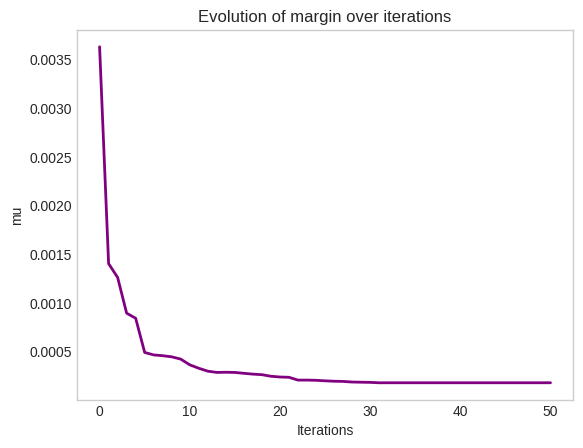

11:28:40 | INFO | ml_moo | Fit runtime: 3.19 seconds


In [ ]:
method = 'mola'
moopt = moo(w_scalar)
moo_solutions[method] = moopt.mo_optimization(method, **opt_params)

In [ ]:
objs = get_objectives(moo_solutions[method])

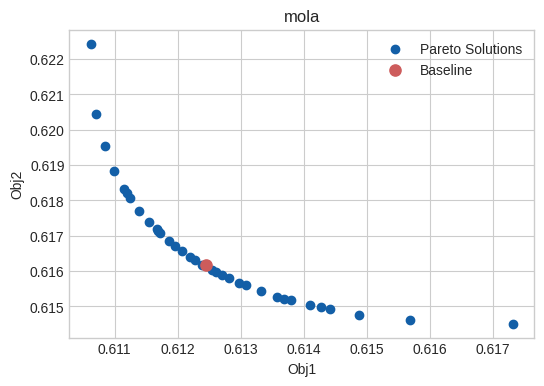

In [ ]:
title="Conflict between losses for white and non-white person in training"
plot_pareto_2d(objectives=objs, 
               labels=("Obj1", "Obj2"), 
               title=method,
               baseline = equal.objs
               )

In [ ]:
hypervolume_values = compute_hypervolume_progress(objs)

In [ ]:
hypervolumes_dic[method] = moo_solutions[method].get_hypervolumes()

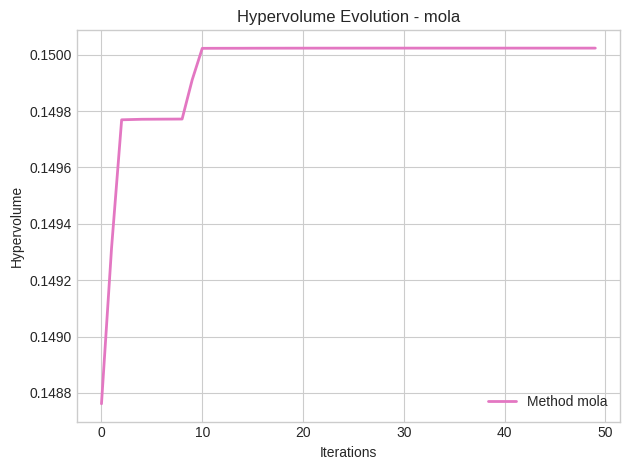

In [ ]:
plot_hypervolume(hypervolume_values=hypervolumes_dic[method], method=method)

### MONISE

In [ ]:
method = 'monise'
moopt = moo(w_scalar)
moo_solutions[method] = moopt.mo_optimization(method, **opt_params)


11:28:40 | WARNING | ml_moo | Ignored parameters for monise: {'target_size', 'target_gap', 'norm', 'node_gap', 'node_time_limit'}
11:28:40 | DEBUG | ml_moo.moo.monise | Finding 1th individual minima


11:28:40 | DEBUG | ml_moo.moo.monise | Finding 2th individual minima
11:28:40 | DEBUG | ml_moo.moo.monise | 3th solution - importance: 1.0
11:28:40 | DEBUG | ml_moo.moo.monise | 4th solution - importance: 0.24957846509316603
11:28:40 | DEBUG | ml_moo.moo.monise | 5th solution - importance: 0.2488958104213706
11:28:40 | DEBUG | ml_moo.moo.monise | 6th solution - importance: 0.06523369320759408
11:28:40 | DEBUG | ml_moo.moo.monise | 7th solution - importance: 0.06415847470206544
11:28:40 | DEBUG | ml_moo.moo.monise | 8th solution - importance: 0.06071315239192798
11:28:40 | DEBUG | ml_moo.moo.monise | 9th solution - importance: 0.058943772688587505


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


11:28:40 | DEBUG | ml_moo.moo.monise | 10th solution - importance: 0.016611817996589118
11:28:40 | DEBUG | ml_moo.moo.monise | 11th solution - importance: 0.01635342637060047
11:28:41 | DEBUG | ml_moo.moo.monise | 12th solution - importance: 0.016296316311391668
11:28:41 | DEBUG | ml_moo.moo.monise | 13th solution - importance: 0.016102407791313802
11:28:41 | DEBUG | ml_moo.moo.monise | 14th solution - importance: 0.0159951011466343


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


...

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


11:28:43 | DEBUG | ml_moo.moo.monise | 37th solution - importance: 0.0011916747672955123
11:28:43 | DEBUG | ml_moo.moo.monise | 38th solution - importance: 0.0010931377362176642


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


11:28:43 | DEBUG | ml_moo.moo.monise | 39th solution - importance: 0.0010662830700663081
11:28:43 | DEBUG | ml_moo.moo.monise | 40th solution - importance: 0.0010391299696760684


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [ ]:
objs = get_objectives(moo_solutions[method])

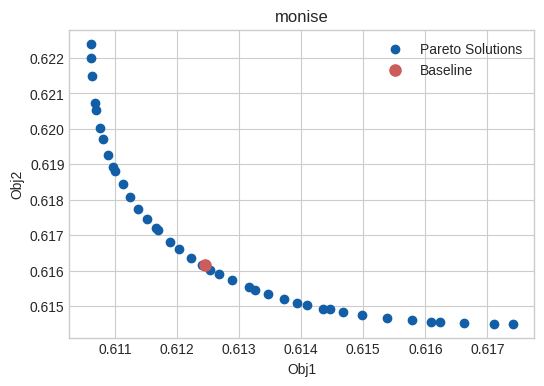

In [ ]:
plot_pareto_2d(objectives=objs, 
               labels=("Obj1", "Obj2"), 
               title=method,
               baseline = equal.objs
               )

In [ ]:
hypervolumes_dic[method] = compute_hypervolume_progress(objs)

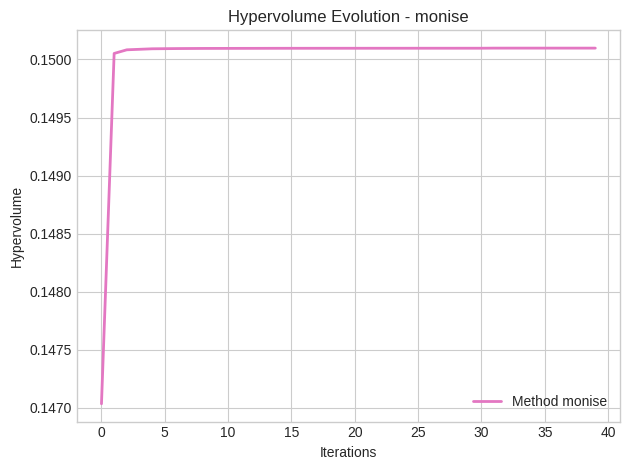

In [ ]:
plot_hypervolume(hypervolume_values=hypervolumes_dic[method], method=method)

### Random Weighted Sum

In [ ]:
method = 'random_weight'
moopt = moo(w_scalar)
moo_solutions[method] = moopt.mo_optimization(method, **opt_params)

11:28:44 | WARNING | ml_moo | Ignored parameters for random_weight: {'target_size', 'target_gap', 'norm', 'node_gap', 'node_time_limit'}
11:28:44 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima


11:28:44 | DEBUG | ml_moo.moo.random_weights | Finding 2th individual minima
11:28:44 | DEBUG | ml_moo.moo.random_weights | 3th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 4th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 5th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 6th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 7th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 8th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 9th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 10th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 11th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 12th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 13th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 14th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 15th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 16th solution
11:28:44 | DEBUG | ml_moo.moo.random_weights | 17th solution
11:28:44 | DEBU

In [ ]:
objs = get_objectives(moo_solutions[method])

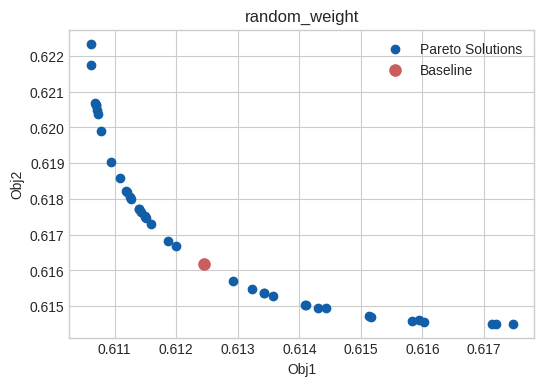

In [ ]:
plot_pareto_2d(objectives=objs, 
               labels=("Obj1", "Obj2"), 
               title=method,
               baseline = equal.objs
               )

In [ ]:
hypervolumes_dic[method] = compute_hypervolume_progress(objs)

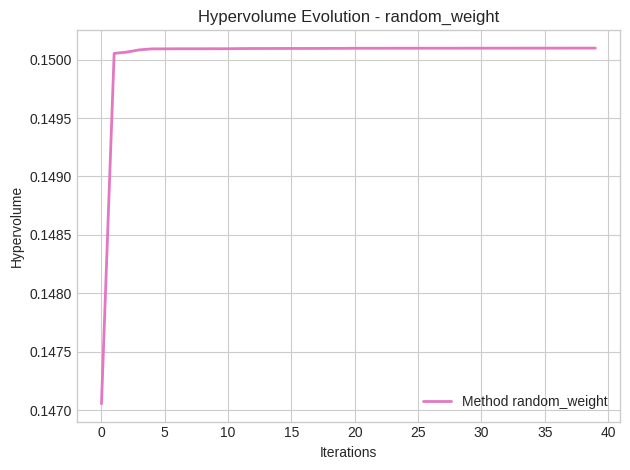

In [ ]:
plot_hypervolume(hypervolume_values=hypervolumes_dic[method], method=method)

## Comparison between MOO methods

In [ ]:
from ml_moo.analysis.visualization import plot_pareto_2d_multiple, plot_multiple_hypervolumes

In [ ]:
pareto_dict={name: get_objectives(sol) for name, sol in moo_solutions.items()}

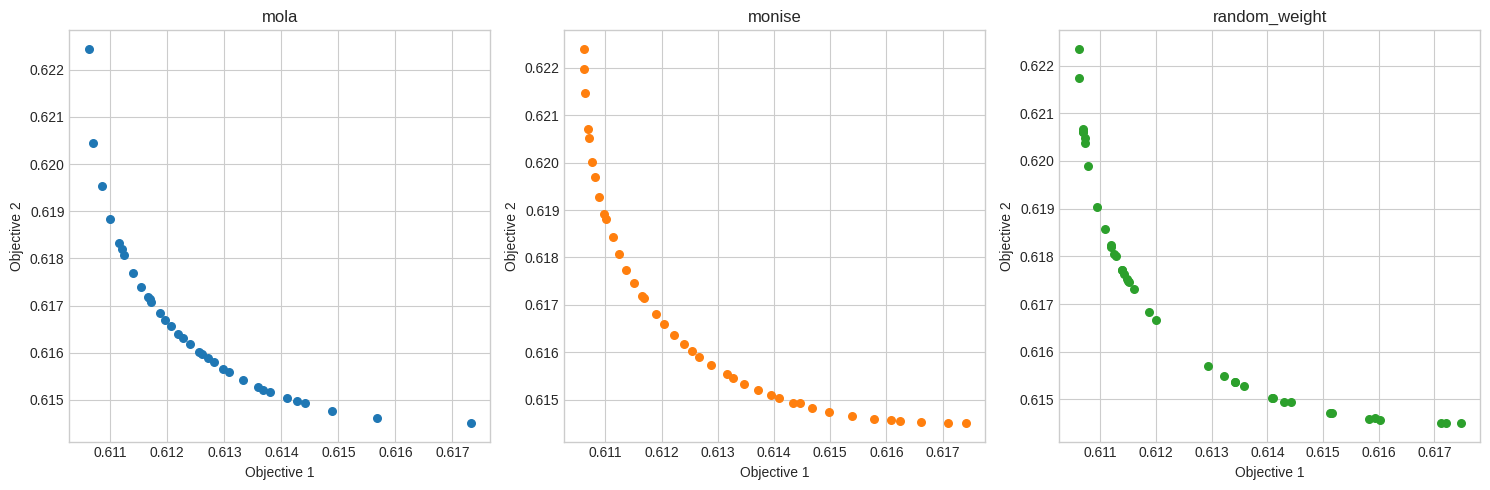

In [ ]:
plot_pareto_2d_multiple(
    pareto_dict=pareto_dict,
    title='2D Pareto Front Comparison'
)


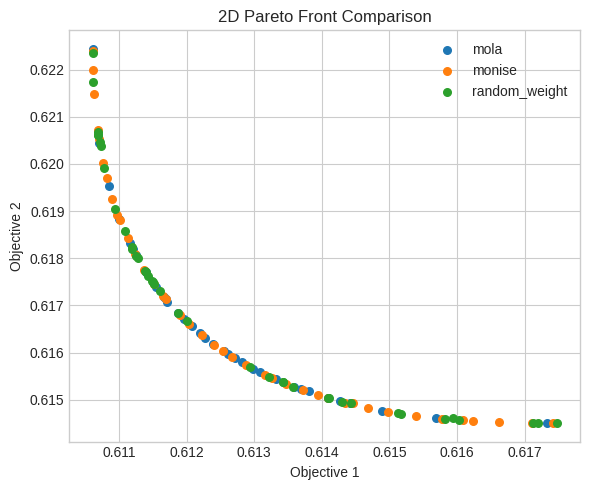

In [ ]:
plot_pareto_2d_multiple(
    pareto_dict=pareto_dict,
    title='2D Pareto Front Comparison',
    show_subplot=False
)

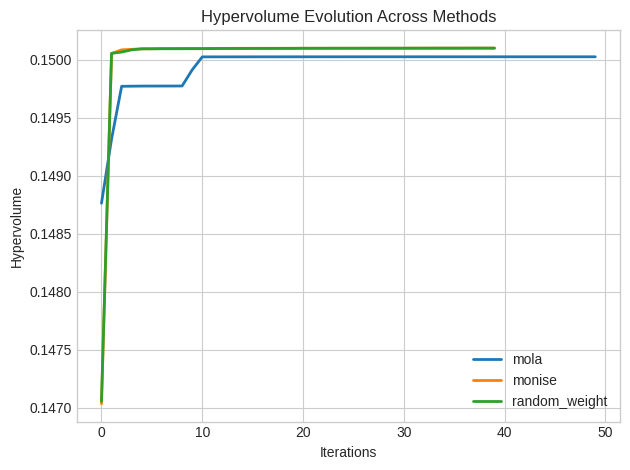

In [ ]:
plot_multiple_hypervolumes(hypervolumes_dic)

In [ ]:
#for name, sol in moo_solutions.items():
name = 'mola'
print(f"\n{name.upper()} ENSEMBLE:")
acc = run_ensemble(moo_solutions[name], X_train, y_train, X_test, y_test)


MOLA ENSEMBLE:
Ensemble Accuracy: 0.6669


In [ ]:
from ml_moo.analysis.moo_analyzer import Analyzer

13:11:19 | WARNING | ml_moo | [Methods have different numbers of solutions: {40, 34}


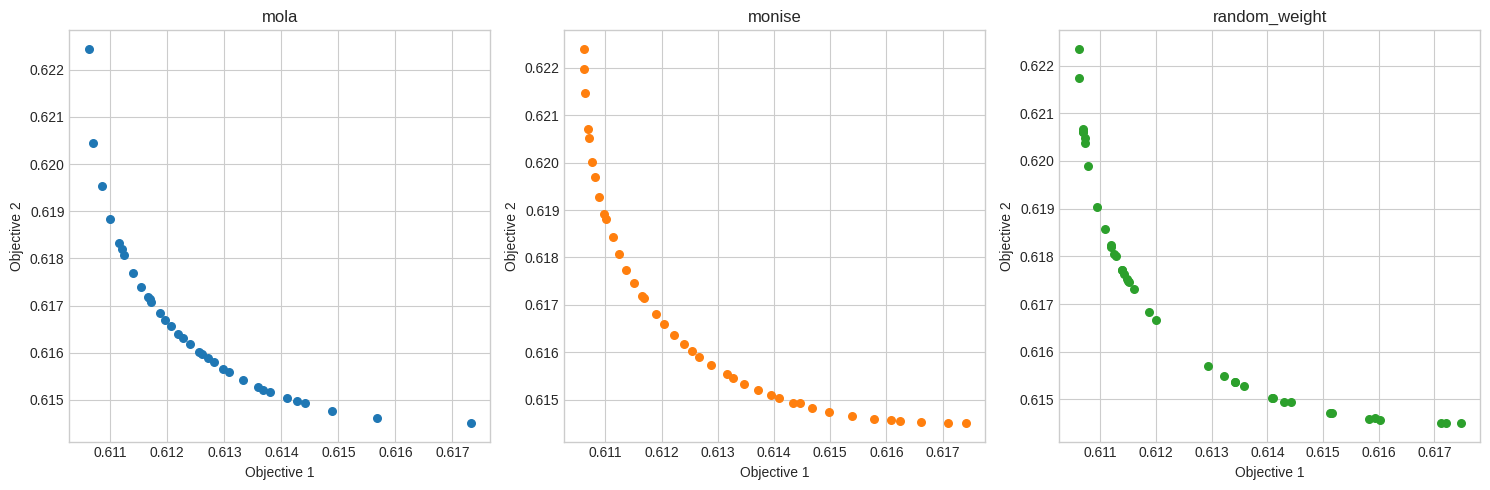

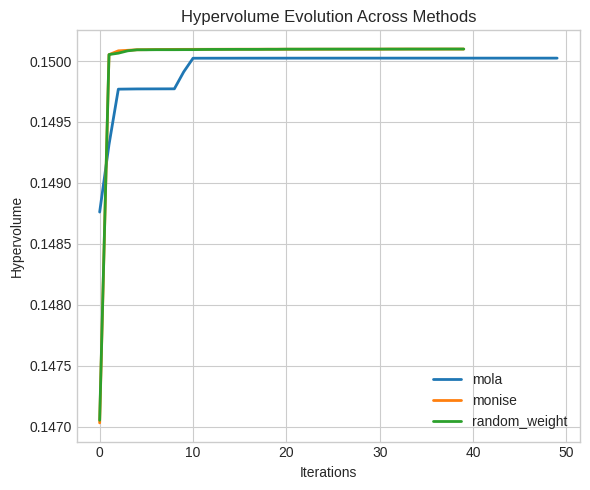

[MLMooAnalyzer] Visualization complete.


In [ ]:
Analyzer.run_multiple(pareto_dict = pareto_dict, 
                      hypervolumes_values = hypervolumes_dic,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True)

## Run experiments

In [ ]:
from ml_moo.tests.experiments.run import run_experiments
from ml_moo.analysis.moo_analyzer import Analyzer

In [ ]:
methods

['mola', 'monise', 'random_weight']

/home/lineccsa/mestrado/moo_research/moopt/moolib/ml_moo/tests/experiments/run.py:53: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  hypervolume_values = solver.get_hypervolumes()
15:01:46 | WARNING | ml_moo | Ignored parameters for mola: {'target_size', 'target_gap', 'norm', 'node_gap', 'node_time_limit'}
15:01:46 | DEBUG | ml_moo | Finding 1th individual minimum
15:01:46 | DEBUG | ml_moo | Finding 2th individual minimum
15:01:46 | DEBUG | ml_moo | Calculated weights: [0.53215716 0.46784284]
15:01:46 | DEBUG | ml_moo | Importance: 0.00360207071806673
15:01:46 | DEBUG | ml_moo | Global lower bound (y*): [0.61060611 0.61451032]
15:01:46 | INFO | ml_moo | Iteration 2
15:01:46 | DEBUG | ml_moo | Solutions list: [array([0.61060611, 0.62220965]), array([0.61737493, 0.61451032])]
15:01:46 | DEBUG | ml_moo | New solution added: [0.61225628 0.61632889]
15:01:46 | DEBUG | ml_moo | Calculated weights: [0.26214724 0.73785276]
15:01:46 | DEBUG | ml_moo | Importance: 0.001363469399707

Running MOLA...


15:01:46 | DEBUG | ml_moo | Calculated weights: [0.77949118 0.22050882]
15:01:46 | DEBUG | ml_moo | Importance: 0.0013059485233195556
15:01:46 | DEBUG | ml_moo | Global lower bound (y*): [0.61060611 0.61451032]
15:01:46 | INFO | ml_moo | Iteration 4
15:01:46 | DEBUG | ml_moo | Solutions list: [array([0.61433771, 0.61494903]), array([0.61225628, 0.61632889]), array([0.61060611, 0.62220965]), array([0.61737493, 0.61451032])]
15:01:46 | DEBUG | ml_moo | New solution added: [0.61103676 0.61868961]
15:01:46 | DEBUG | ml_moo | Calculated weights: [0.3986557 0.6013443]
15:01:46 | DEBUG | ml_moo | Importance: 0.0008758577346670293
15:01:46 | DEBUG | ml_moo | Global lower bound (y*): [0.61060611 0.61451032]
15:01:46 | INFO | ml_moo | Iteration 5
15:01:46 | DEBUG | ml_moo | Solutions list: [array([0.61103676, 0.61868961]), array([0.61433771, 0.61494903]), array([0.61225628, 0.61632889]), array([0.61060611, 0.62220965]), array([0.61737493, 0.61451032])]
15:01:46 | DEBUG | ml_moo | New solution ad

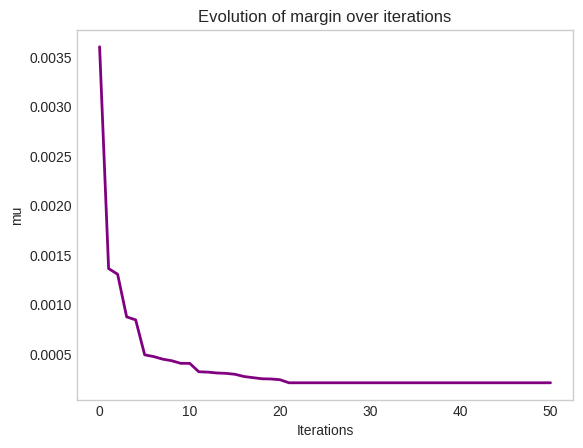

15:01:51 | INFO | ml_moo | Fit runtime: 5.08 seconds
15:01:51 | WARNING | ml_moo | Ignored parameters for monise: {'target_size', 'target_gap', 'norm', 'node_gap', 'node_time_limit'}
15:01:51 | DEBUG | ml_moo.moo.monise | Finding 1th individual minima
15:01:51 | DEBUG | ml_moo.moo.monise | Finding 2th individual minima
15:01:51 | DEBUG | ml_moo.moo.monise | 3th solution - importance: 1.0
15:01:51 | DEBUG | ml_moo.moo.monise | 4th solution - importance: 0.25124618312136754
15:01:51 | DEBUG | ml_moo.moo.monise | 5th solution - importance: 0.24786866196354723
15:01:51 | DEBUG | ml_moo.moo.monise | 6th solution - importance: 0.06490067837450098


Running MONISE...
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


15:01:51 | DEBUG | ml_moo.moo.monise | 7th solution - importance: 0.0630012941780475
15:01:51 | DEBUG | ml_moo.moo.monise | 8th solution - importance: 0.06259638881121725
15:01:51 | DEBUG | ml_moo.moo.monise | 9th solution - importance: 0.05875621216017041
15:01:51 | DEBUG | ml_moo.moo.monise | 10th solution - importance: 0.0164510604671384
15:01:51 | DEBUG | ml_moo.moo.monise | 11th solution - importance: 0.016359373502515536


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


15:01:51 | DEBUG | ml_moo.moo.monise | 12th solution - importance: 0.01601851699445217
15:01:51 | DEBUG | ml_moo.moo.monise | 13th solution - importance: 0.015993487758801394
15:01:51 | DEBUG | ml_moo.moo.monise | 14th solution - importance: 0.015672186367110576


...

15:01:54 | DEBUG | ml_moo.moo.monise | 38th solution - importance: 0.0009889552141499336
15:01:54 | DEBUG | ml_moo.moo.monise | 39th solution - importance: 0.0009409744345811823


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


15:01:54 | DEBUG | ml_moo.moo.monise | 40th solution - importance: 0.0009313073352433861
15:01:54 | WARNING | ml_moo | Ignored parameters for random_weight: {'target_size', 'target_gap', 'norm', 'node_gap', 'node_time_limit'}
15:01:54 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Running RANDOM_WEIGHT...


15:01:54 | DEBUG | ml_moo.moo.random_weights | Finding 2th individual minima
15:01:54 | DEBUG | ml_moo.moo.random_weights | 3th solution
15:01:54 | DEBUG | ml_moo.moo.random_weights | 4th solution
15:01:54 | DEBUG | ml_moo.moo.random_weights | 5th solution
15:01:54 | DEBUG | ml_moo.moo.random_weights | 6th solution
15:01:54 | DEBUG | ml_moo.moo.random_weights | 7th solution
15:01:54 | DEBUG | ml_moo.moo.random_weights | 8th solution
15:01:54 | DEBUG | ml_moo.moo.random_weights | 9th solution
15:01:54 | DEBUG | ml_moo.moo.random_weights | 10th solution
15:01:54 | DEBUG | ml_moo.moo.random_weights | 11th solution
15:01:55 | DEBUG | ml_moo.moo.random_weights | 12th solution
15:01:55 | DEBUG | ml_moo.moo.random_weights | 13th solution
15:01:55 | DEBUG | ml_moo.moo.random_weights | 14th solution
15:01:55 | DEBUG | ml_moo.moo.random_weights | 15th solution
15:01:55 | DEBUG | ml_moo.moo.random_weights | 16th solution
15:01:55 | DEBUG | ml_moo.moo.random_weights | 17th solution
15:01:55 | DEBU

In [ ]:
experiment_results, pareto_dict, hypervolumes_dic = run_experiments(
                                                            methods = methods,
                                                            opt_params = opt_params,
                                                            model = model,
                                                            train_fn = train_fn_logreg,
                                                            num_objs = num_objs
                                                            )

In [ ]:
experiment_results

{'mola': {'solver': <ml_moo.moo.mola.Mola at 0x7b8599cbc320>,
  'objectives': array([[0.61294353, 0.61569119],
         [0.61291371, 0.61571172],
         [0.6120586 , 0.61657338],
         [0.6131181 , 0.61556529],
         [0.61169487, 0.61711793],
         [0.61119992, 0.61822521],
         [0.6139038 , 0.61511142],
         [0.61084325, 0.61954694],
         [0.61185017, 0.61687251],
         [0.61498441, 0.61475444],
         [0.61248219, 0.61610309],
         [0.61072286, 0.62028418],
         [0.61570947, 0.61460387],
         [0.61132032, 0.61788378],
         [0.61360585, 0.61526803],
         [0.61193662, 0.61675252],
         [0.61273907, 0.61585582],
         [0.61155622, 0.61736191],
         [0.61316891, 0.61555414],
         [0.61102645, 0.61872606],
         [0.61432662, 0.61494999],
         [0.61223841, 0.61634912],
         [0.61060677, 0.62227715],
         [0.61736603, 0.61450934]]),
  'models': [LogisticRegression(C=2.688117141816135e+43, tol=0.001, warm_start=Tru

15:02:23 | WARNING | ml_moo | [Methods have different numbers of solutions: {24, 40}


num_objectives 2


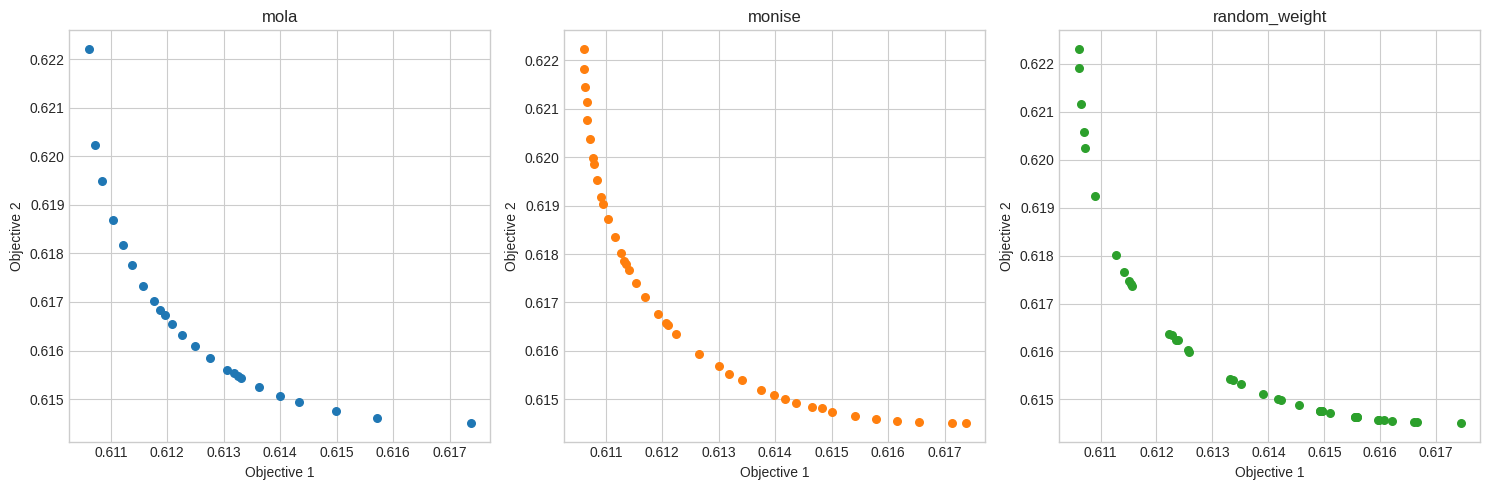

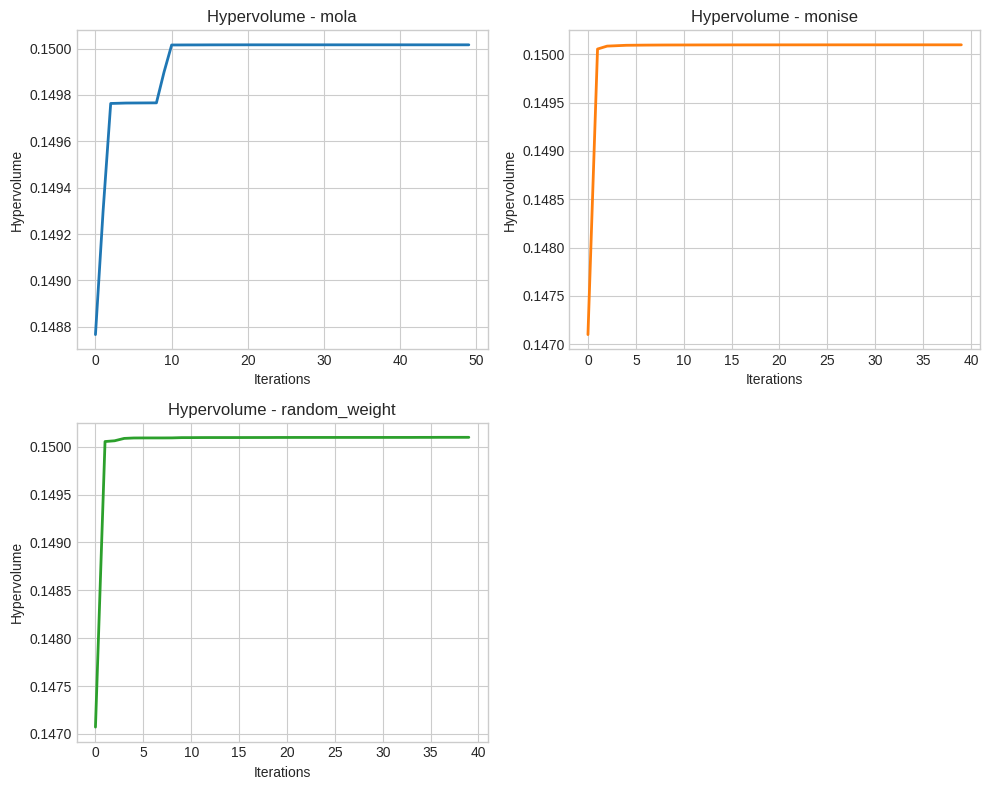

[MLMooAnalyzer] Visualization complete.


In [ ]:
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dic,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True
                      )